# Long-history pipeline - data exploration
Runs every analysis from `eda_lib`. Same cached matrix as `run_explore.py`. Nothing in `long_history/` or `v2/` is modified.

In [1]:
import sys
from pathlib import Path
HERE = Path.cwd()
sys.path.insert(0, str(HERE))
import eda_lib as L, plots as P
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
d = L.load_frames()
d.head()

,date,demand,floortables,demand_per_table,year,month,dow
0,2015-01-01,5890,210,28.047619,2015,1,3
1,2015-01-02,5821,220,26.459091,2015,1,4
2,2015-01-03,5347,220,24.304545,2015,1,5
3,2015-01-04,5136,220,23.345455,2015,1,6
4,2015-01-05,5029,220,22.859091,2015,1,0


## A1 - descriptive statistics: what does the raw series look like?

In [2]:
pd.DataFrame({c: L.describe_series(d, c) for c in ['demand','floortables','demand_per_table']})

,demand,floortables,demand_per_table
count,4166.000000,4166.000000,4166.000000
span_days,4166.000000,4166.000000,4166.000000
gaps,0.000000,0.000000,0.000000
min,0.000000,0.000000,0.000000
p10,745.500000,209.000000,2.503344
median,4239.500000,284.000000,18.815121
mean,4202.704513,260.319971,16.539371
p90,6984.000000,299.000000,25.226872
max,8785.000000,321.000000,32.011070
std,2121.554934,44.880411,8.038538


In [3]:
L.describe_by_regime(d)[['demand_per_table_mean','demand_per_table_cv','n']].round(2)

,demand_per_table_mean,demand_per_table_cv,n
regime,,,
pre_covid,19.99,0.16,1848
covid,4.60,0.75,1074
recovery,16.28,0.21,365
current,23.98,0.13,879


In [4]:
L.describe_by(d, 'dow', ['demand_per_table'])[['demand_per_table_mean']].round(2)

,demand_per_table_mean
dow,
0,15.50
1,15.64
2,16.00
3,16.26
4,17.14
5,18.40
6,16.85


## A2 - is monthly seasonality the same shape every year?

mean year-to-year shape corr: 0.048
unstable months: [1, 2, 11, 12]


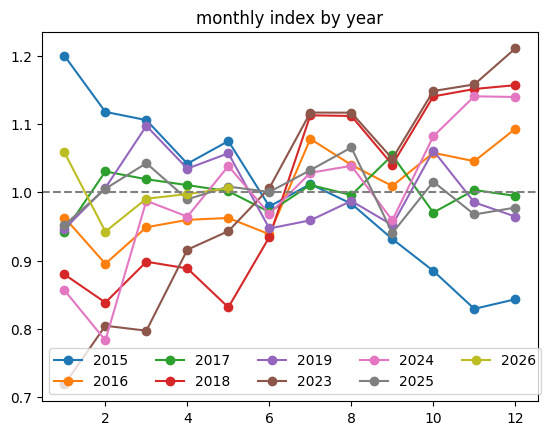

In [5]:
mi = L.monthly_index_by_year(d)
ma = L.monthly_alignment(mi)
print('mean year-to-year shape corr:', round(ma['mean_offdiag_corr'], 3))
print('unstable months:', ma['unstable_months'])
for yr in mi.index:
    plt.plot(range(1,13), mi.loc[yr], 'o-', label=int(yr))
plt.axhline(1, ls='--', c='grey'); plt.legend(ncol=5)
plt.title('monthly index by year'); plt.show()

## A3 - is each holiday's impact the same every year?

In [6]:
mult = L.holiday_multiplier_by_year(d)
L.holiday_alignment(mult)[['n_clean_years','cv_per_table','min_year_mult','max_year_mult','verdict']]

,n_clean_years,cv_per_table,min_year_mult,max_year_mult,verdict
holiday,,,,,
Christmas,7,0.041851,0.969042,1.122137,consistent
DragonBoat,7,0.046189,0.916216,1.035806,consistent
Easter,8,0.065708,0.946892,1.144655,consistent
GoldenWeek,7,0.072393,0.935839,1.194917,consistent
Labour,8,0.074704,0.932069,1.195682,consistent
ChingMing,8,0.079689,0.812850,1.077382,consistent
MidAutumn,7,0.096622,0.749368,1.036085,consistent
CNY,8,0.285447,0.849323,1.761512,variable
NewYear,8,0.428280,0.848799,2.699607,variable


In [7]:
L.cny_trough_by_year(d)   # pre-CNY trough depth by year (min over offsets -7..-1)

,min_mult_offset,min_mult_value
2016,-1.0,0.494715
2017,-1.0,0.490111
2018,-1.0,0.393110
2019,-1.0,0.519341
2023,-1.0,0.965155
2024,-1.0,0.466191
2025,-1.0,0.458120
2026,-1.0,0.483194


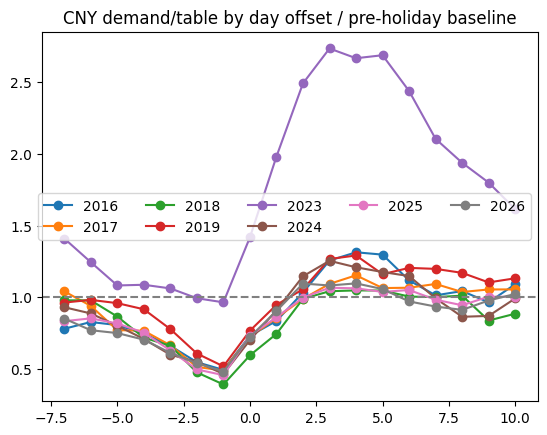

In [8]:
shape = L.holiday_offset_shape_by_year(d, 'CNY')
for yr in shape.index:
    plt.plot(shape.columns, shape.loc[yr], 'o-', label=int(yr))
plt.axhline(1, ls='--', c='grey'); plt.legend(ncol=5)
plt.title('CNY demand/table by day offset / pre-holiday baseline'); plt.show()

## A4 - the COVID years, kept separate

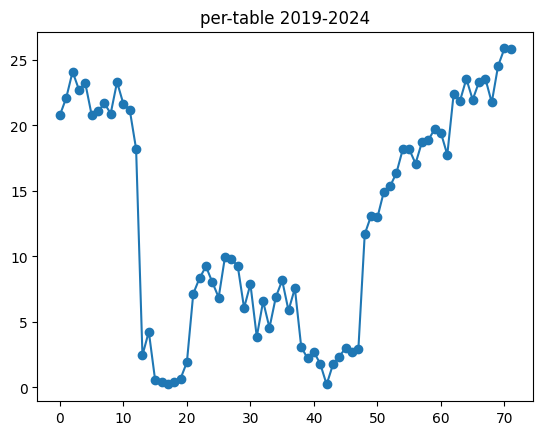

{'jan_per_table': 11.696299492933436,
 'dec_per_table': 19.717229474592727,
 'climbed': True,
 'norm_2024_h1': 21.18745533365394,
 'reached_norm': False}

In [9]:
ct = L.covid_timeline(d)
plt.plot(range(len(ct)), ct['mean_per_table'], 'o-')
plt.title('per-table 2019-2024'); plt.show()
L.recovery_2023_check(d)

## B1 - one row of the feature matrix after feature engineering

In [10]:
mat = L.build_matrix()
feats = L.feature_names(mat)
print(len(feats), 'features')
L.sample_wide(mat)

174 features


,normal_midweek,normal_saturday,cny_dm3,cny_dp1,goldenweek,jan2026_a,jan2026_b,__group__
dow,2.000000,5.000000,5.000000,2.000000,3.000000,0.000000,3.000000,calendar
day,19.000000,22.000000,14.000000,18.000000,2.000000,26.000000,29.000000,calendar
week_of_month,3.000000,4.000000,2.000000,3.000000,1.000000,4.000000,5.000000,calendar
month,11.000000,11.000000,2.000000,2.000000,10.000000,1.000000,1.000000,calendar
quarter,4.000000,4.000000,1.000000,1.000000,4.000000,1.000000,1.000000,calendar
...,...,...,...,...,...,...,...,...
MidAutumn_x_recent,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,holiday_flag
week_of_year,47.000000,47.000000,7.000000,8.000000,40.000000,5.000000,5.000000,calendar
woy_sin,-0.568065,-0.568065,0.748511,0.822984,-0.992709,0.568065,0.568065,calendar
woy_cos,0.822984,0.822984,0.663123,0.568065,0.120537,0.822984,0.822984,calendar


In [11]:
L.feature_dictionary(mat).head(20)

,group,dtype,pct_nonnull_all,pct_nonnull_trainable,min,mean,max
feature,,,,,,,
dow,calendar,int32,100.0,100.0,0.000000,3.000000,6.000000
day,calendar,int32,100.0,100.0,1.000000,15.716275,31.000000
week_of_month,calendar,int32,100.0,100.0,1.000000,2.698032,5.000000
month,calendar,int32,100.0,100.0,1.000000,6.396543,12.000000
quarter,calendar,int32,100.0,100.0,1.000000,2.468795,4.000000
year,calendar,int32,100.0,100.0,2015.000000,2020.213154,2026.000000
day_of_year,calendar,int32,100.0,100.0,1.000000,179.277244,366.000000
is_weekend,calendar,int32,100.0,100.0,0.000000,0.285646,1.000000
is_friday,calendar,int32,100.0,100.0,0.000000,0.142823,1.000000


## B2 - which features are redundant, which track the target

In [12]:
cf = L.corr_frames(mat)
L.high_corr_pairs(cf['pearson']).head(20)

,feat_a,feat_b,group_a,group_b,r
0,lag_182,lag_anchor_182,short_lag,short_lag,1.000000
1,lag_7,lag_anchor_7,short_lag,short_lag,1.000000
2,lag_21,lag_anchor_21,short_lag,short_lag,1.000000
3,lag_28,lag_anchor_28,short_lag,short_lag,1.000000
4,lag_56,lag_anchor_56,short_lag,short_lag,1.000000
5,lag_91,lag_anchor_91,short_lag,short_lag,1.000000
6,lag_365,lag_anchor_365,yearly_lookback,yearly_lookback,1.000000
7,lag_14,lag_anchor_14,short_lag,short_lag,1.000000
8,rolling_mean_28,ewma_28,recency_aggregate,recency_aggregate,0.997141
9,doy_sin,woy_sin,calendar,calendar,0.996812


In [13]:
L.target_corr(mat).head(15)

,pearson,spearman
feature,,
same_dow_mean_8w,0.883231,0.892762
same_dow_mean_4w,0.868618,0.873476
lag_14,0.855671,0.858486
ewma_28,0.867078,0.855120
rolling_mean_28,0.863174,0.852990
lag_7,0.845047,0.851394
ewma_14,0.863443,0.849849
rolling_mean_14,0.861884,0.848099
lag_2,0.859971,0.844814


## B3 - SHAP feature importance (LightGBM native pred_contrib)

In [14]:
g = L.shap_global(mat, feats, horizons=[1,7,14,28], sample=2000)
g['mean_abs_shap'].head(20)

same_dow_mean_8w           235.779095
rolling_max_28             213.578108
rolling_max_14             155.723193
lag_2                      151.967906
rolling_mean_28            104.827824
mainland_block_pos_norm     74.886339
ewma_28                     70.375381
lag_35                      62.753889
rolling_mean_14             54.208662
mainland_block_length       38.510131
doy_sin                     37.496937
dow_cos                     36.899567
lag_42                      34.169377
days_from_last_holiday      31.074898
dow                         29.678572
lag_91                      29.440142
holiday_yoy_lag             28.550929
ewma_14                     27.015096
year                        26.695486
days_to_next_holiday        25.412795
Name: mean_abs_shap, dtype: float64

### Local: the mid-January 2026 forecast (full-history vs walk-forward)

In [15]:
actual = dict(zip(d['date'], d['demand'].astype(float)))
fh = L.shap_local(mat, feats, horizon=7, actual_by_date=actual)
wf = L.shap_local_walkforward(mat, feats, ['jan2026_a','jan2026_b'], horizon=7, actual_by_date=actual)
for lbl in ['jan2026_a','jan2026_b']:
    print(lbl, 'full-history :', fh[lbl+'__meta__'].round(1).to_dict('records')[0])
    print(lbl, 'walk-forward :', wf[lbl+'__meta__'].round(1).to_dict('records')[0])

jan2026_a full-history : {'base_value': 5206.7, 'prediction': 6922.7, 'actual': 7011.0, 'pct_error': -1.3}
jan2026_a walk-forward : {'base_value': 5129.0, 'prediction': 6799.7, 'actual': 7011.0, 'pct_error': -3.0}
jan2026_b full-history : {'base_value': 5206.7, 'prediction': 7306.2, 'actual': 7280.0, 'pct_error': 0.4}
jan2026_b walk-forward : {'base_value': 5130.2, 'prediction': 7136.7, 'actual': 7280.0, 'pct_error': -2.0}


In [16]:
wf['jan2026_a'].head(15)   # top SHAP contributions, walk-forward

,feature_value,shap
rolling_max_14,8129.000000,441.819692
same_dow_mean_8w,6845.714286,429.717434
rolling_max_28,8575.000000,362.986646
rolling_min_14,6956.000000,188.088122
rolling_mean_14,7526.214286,94.959361
lag_35,7093.000000,86.306513
dow,0.000000,-59.809486
mainland_block_pos_norm,0.000000,-49.291594
rolling_min_28,6611.000000,42.813328
lag_365,4576.000000,-42.225768


  -> D:\Applications\Work\Models\Demand Forecast v2\research\explore_longhistory\output\nb_waterfall.png


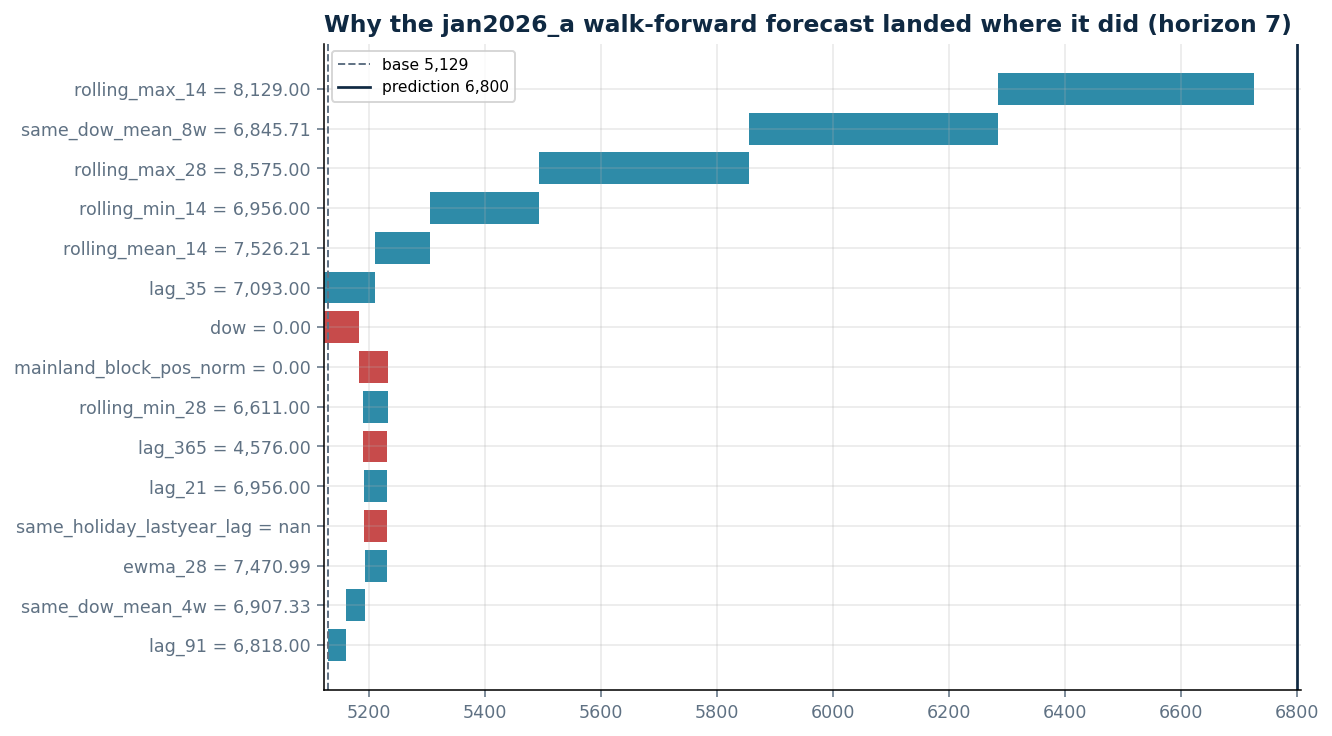

In [17]:
P.plot_shap_waterfall(wf['jan2026_a'], wf['jan2026_a__meta__'], 'jan2026_a walk-forward', HERE/'output'/'nb_waterfall.png')
from IPython.display import Image
Image(str(HERE/'output'/'nb_waterfall.png'))